In [1]:
import sys

import os

In [2]:
import torch
from torch import nn
from torch.nn import functional as F


import wandb
import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from torch.utils.data import DataLoader
from xaikd.utils import metrics
from xaikd import models, datasets

from contextlib import nullcontext

from datetime import datetime

from matplotlib import colormaps

from xaikd.models.vgg import canonize_model


from zennit.attribution import Gradient
from zennit.composites import EpsilonGammaBox, EpsilonPlusFlat
from xaikd import datasets, models, utils

from torchvision import transforms

from collections import OrderedDict

In [3]:
api = wandb.Api()

In [4]:
PROJECT = "p16i/xaikd-distillation-layerwise-s27"
EXPERIMENT_GROUP = "./artifacts/2024-05-s27/experiments/6-ignore-layer-loss-fullupdate"

In [6]:
def read_data(
    teacher,
    student,
    dataset,
    policy,
    lambda_task,
    lambda_kd,
    lambda_layer,
    training_size,
    contamination_level,
    parameter_partition_mode,
    ignore_layer_loss_fullupdate,
    verbose=False,
    return_raw = False,
    accuracy_mode="last_checkpoint",
    layers="features.23:layer3,features.30:layer4"
):
    
    
    runs = api.runs(
        PROJECT,
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.lambda_layer": lambda_layer},
            {"config.policy": policy},
            {"config.dataset": dataset},
            {"config.training_size": training_size},
            {"config.parameter_partition_mode": parameter_partition_mode},
            {"config.ignore_layer_loss_fullupdate": ignore_layer_loss_fullupdate},
            {"config.layers": layers}
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    
    datasets = []
    for run in runs:
        seed = run.config["seed"]
        if not "arr_metrics"in run.summary:
            print(">> bad run config (id={rn}")
            print(run.config)
            count += 1
            return run
            continue
                                 
        if accuracy_mode == "last_checkpoint":
            k = -1
        else:
            raise
    
        datasets.append(run.config["dataset"])

        for epoch in range(run.config["epochs"]):
            
            epoch_val_acc = run.summary["arr_metrics"]["val_acc"][epoch]
        
            epoch_train_acc = run.summary["arr_metrics"]["train_acc"][epoch]


            rows.append(
                dict(
                    best_epoch=k,
                    seed=seed, 
                    lambda_task=run.config["lambda_task"],
                    lambda_kd=run.config["lambda_kd"],
                    # remark: this is the actual value used in distillation
                    # cf. https://github.com/p16i/xai-kd/blob/2023-09-s14--1-teacher-training-script/scripts/distill-layerwise.py#L364
                    lambda_layer=run.config["policy_lambda_layer"],
                    epoch=epoch,
                    val_acc=epoch_val_acc, 
                    train_acc=epoch_train_acc,
                    teacher_acc=run.summary["teacher_acc"],
                    policy=run.config["policy"],
                    run_id=run.id
                )
            )

    if count != 0:
        print(f"We have {count} bad run! abort!")
        raise
    
    df = pd.DataFrame(rows)
    # df = df.sort_values(by=["lambda_layer", "seed"], ascending=True)
        
        
    if return_raw:
        return df
        
    df = df.groupby(by="epoch").agg(
        {
            "val_acc": ["mean", "std", "count"],
            "train_acc": ["mean", "std", "count"],

            "teacher_acc": ["mean"],
        }
    ).reset_index()
    
    np.testing.assert_allclose(
        df["val_acc"]["count"].values,
        3
    )
    
    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="imagenet-vgg16-tv",
    dataset="imagenet-butterfly-spurious0.5",
    student="vggcustomimagenetdims-32-24-24-10",
    lambda_task=0.0,
    lambda_kd=1.0,
    lambda_layer=1.0,
    policy="attention-transfer",
    #policy="basis-identity:pca--uncentered",

    training_size=0.125,
    verbose=True,
    contamination_level=0.0,
    parameter_partition_mode="@50",
    ignore_layer_loss_fullupdate=True,
    return_raw=False,
)

summary

we have 3 runs
df.shape: (100, 8)


epoch   val_acc                 train_acc                 teacher_acc
              mean       std count      mean       std count        mean
0      0  0.185556  0.032717     3  0.175926  0.016038     3    0.956667
1      1  0.207778  0.047180     3  0.192044  0.033279     3    0.956667
2      2  0.213333  0.043589     3  0.200960  0.052704     3    0.956667
3      3  0.224444  0.057381     3  0.209877  0.053705     3    0.956667
4      4  0.235556  0.074262     3  0.213992  0.057641     3    0.956667
..   ...       ...       ...   ...       ...       ...   ...         ...
95    95  0.596667  0.136504     3  0.696159  0.109414     3    0.956667
96    96  0.613333  0.102686     3  0.709534  0.096868     3    0.956667
97    97  0.615556  0.109358     3  0.711248  0.107225     3    0.956667
98    98  0.605556  0.080300     3  0.710905  0.106996     3    0.956667
99    99  0.621111  0.120062     3  0.717421  0.101932     3    0.956667

[100 rows x 8 columns]

In [7]:
def alias(name):
        __dd = {
            "basis-identity:random--uncentered": "Random Subspace",
            "basis-identity:pca--uncentered": "PCA",
            "basis-identity:pcalookahead--uncentered": "PCA-AH",
            "basis-identity:prca-sortabs--uncentered": "PRCA-sortabs",
            "vid": "VID",
            "nothing": "KD Only"

        }
        return __dd.get(name, name)
    
def color(name):
        __dd = {
            "basis-identity:random--uncentered": "lightgray"
        }
        return __dd.get(name, None)
    
def marker(name):
    if "pca" in name or "prca" in name:
        return "s"
    elif "vid" in name:
        return "x"
    else:
        return '.'

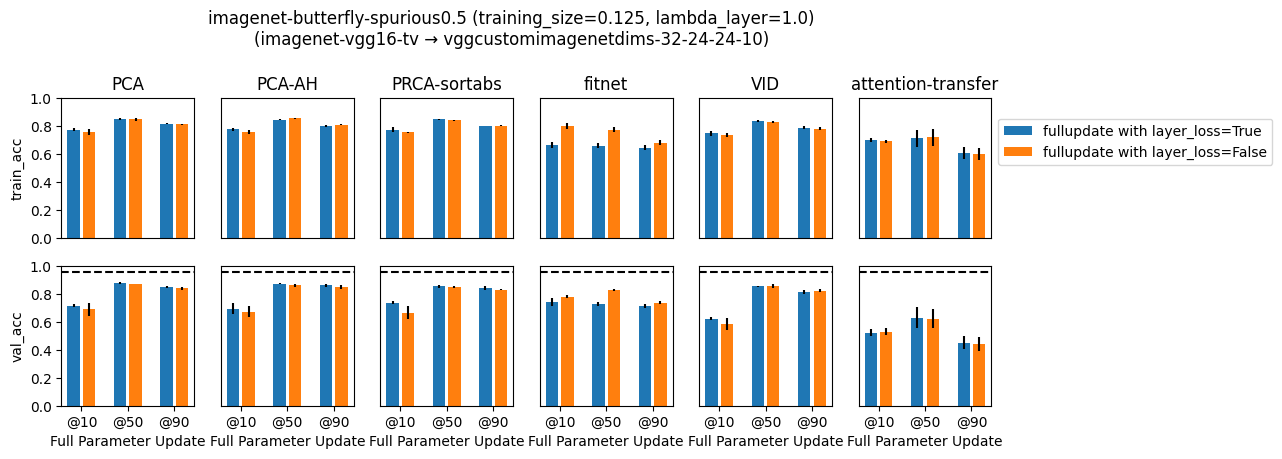

In [38]:
def ls(name):
    return '-'
    
    if name == "@0":
        return "-"
    else:
        return "--"
        
def viz(
    dataset, lambda_layer,
    teacher,
    student, 
    arr_policies = [
        "basis-identity:pca--uncentered",
        "basis-identity:pcalookahead--uncentered",
        "basis-identity:prca-sortabs--uncentered",

        "fitnet", "vid", "attention-transfer",
    ],
    layers="features.23:layer3,features.30:layer4"
):

    
    lambda_task = 0.0
    lambda_kd = 1.0
 

    arr_parameter_modes = [
#        "@0",
        "@10",
        "@50",
        "@90",
 #       "@100"
    ]
    
    trainining_size = 0.125
    ncols = len(arr_policies)
    nrows = 2
    num_policies = len(arr_policies)
    
    plt.figure(figsize=(2*ncols, 2*nrows))

    plt.suptitle(f"{dataset} (training_size={trainining_size}, lambda_layer={lambda_layer})\n({teacher} → {student})", y=1.1)


    cmap = plt.cm.Blues

    ticks = np.arange(len(arr_parameter_modes))
    
    for pix, policy in enumerate(arr_policies):

        for dix, col_name in enumerate(["train_acc", "val_acc"]):
            plt.subplot(nrows, ncols, dix*ncols + pix+1)

            
            for ilx, ignore_layer_loss in enumerate([False, True]):
                stats = np.zeros(
                    (len(arr_parameter_modes), 2)
                )
                
                for mix, parameter_partition_mode in enumerate(arr_parameter_modes):
                    df = read_data(
                        teacher=teacher,
                        dataset=dataset,
                        student=student,
                        lambda_task=lambda_task,
                        lambda_kd=lambda_kd,
                        lambda_layer=lambda_layer,
                        policy=policy,
                        training_size=trainining_size,
                        contamination_level=0.0,
                        parameter_partition_mode=parameter_partition_mode,
                        ignore_layer_loss_fullupdate=ignore_layer_loss,
                        layers=layers
                    )
                    mean = df[col_name]["mean"]
                    stderr = df[col_name]["std"] / (df[col_name]["count"].values[-1] ** 0.5)
                    
                    stats[mix, :] = mean.values[-1], stderr.values[-1]
                plt.bar(
                    ticks * 3 + ilx, 
                    stats[:, 0],
                    yerr=stats[:, 1],
                    label=f"fullupdate with layer_loss={not ignore_layer_loss}"
                )
            
            if dix == 0:
                plt.title(alias(policy))
                
            if col_name == "val_acc":
                teacher_acc = df["teacher_acc"].values[0] 
                plt.axhline(teacher_acc, ls="--", label="Teacher", color="k")
                plt.xlabel("Full Parameter Update")
                plt.xticks(ticks * 3  + 0.5 , arr_parameter_modes)
            else:
                plt.xticks([])
            plt.ylim([0.0, 1])

            if pix == len(arr_policies) - 1 and dix == 0:
                plt.legend(bbox_to_anchor=(1.0, 0.9))
            if pix ==  0 :
                plt.ylabel(col_name)
            else:
                plt.yticks([])

            
viz(
    dataset="imagenet-butterfly-spurious0.5", 
    lambda_layer=1.0,
    teacher="imagenet-vgg16-tv",
    student="vggcustomimagenetdims-32-24-24-10"
)

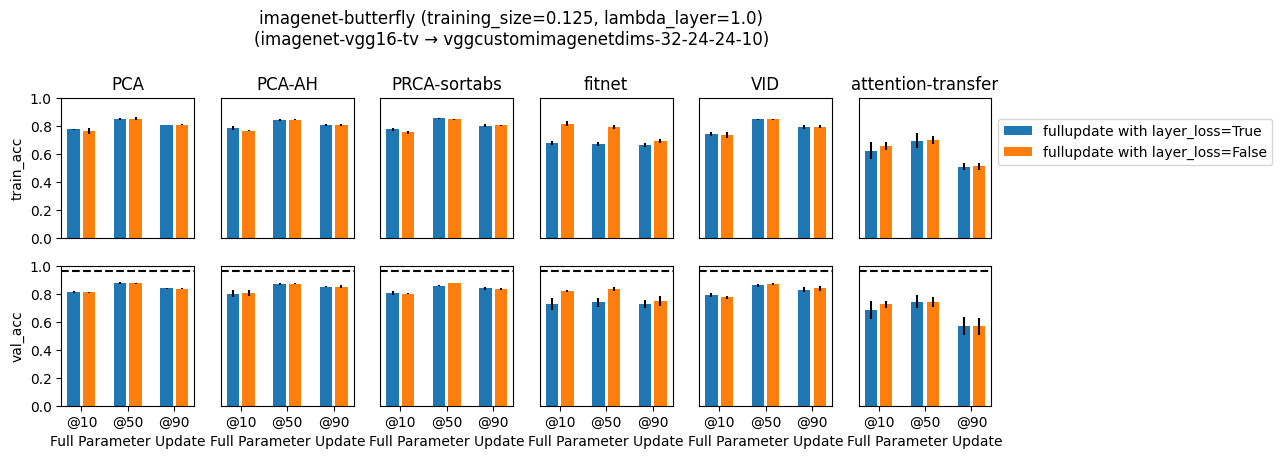

In [40]:
viz(
    dataset="imagenet-butterfly", 
    lambda_layer=1.0,
    teacher="imagenet-vgg16-tv",
    student="vggcustomimagenetdims-32-24-24-10"
)

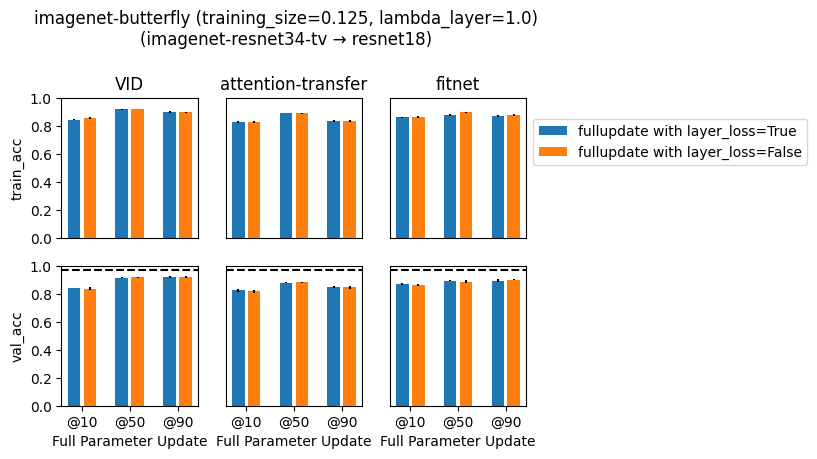

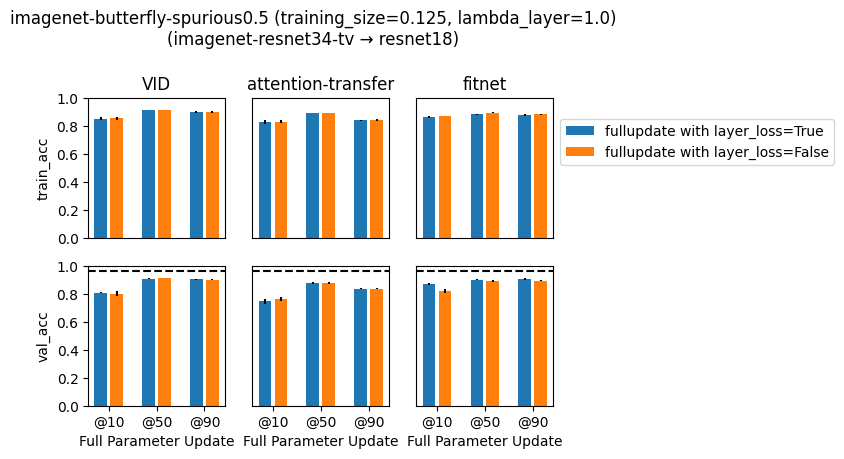

In [41]:
for dataset in ["imagenet-butterfly", "imagenet-butterfly-spurious0.5"]:
    viz(
        dataset=dataset, 
        lambda_layer=1.0,
        teacher="imagenet-resnet34-tv",
        student="resnet18",
        arr_policies=["vid", "attention-transfer", "fitnet"],
        layers="layer3:layer3,layer4:layer4"
    )

# Viz Heatmaps

In [17]:
ds = datasets.construct("imagenet-butterfly")

ds_val = ds.create_subset(train_split=False)
ds_val.transform = lambda x: x

We have 300 images in classes [321, 322, 323, 324, 325, 326]


preparing `ImageNetButterfly` samples: 100%|█████████████| 300/300 [00:00<00:00, 279496.05it/s]


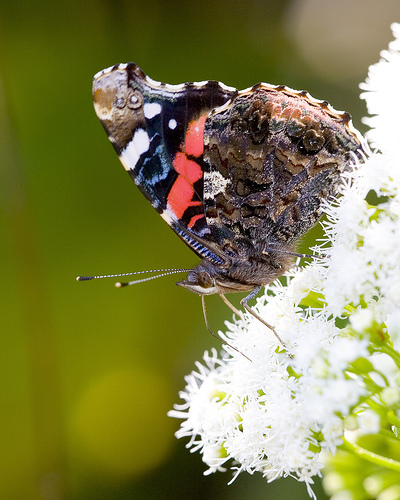

In [18]:
image, label = ds_val[2]
image

In [19]:
ds.selected_classes

[321, 322, 323, 324, 325, 326]

In [20]:
teacher_label, student_label = ds.selected_classes[label], label

teacher_label, student_label

(321, 0)

In [21]:
teacher_model = models.get_trained_model("imagenet-vgg16-tv")

In [22]:
input_transform = ds.input_transformation

input_transform

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [23]:
rc_transform = transforms.Compose(
    [transforms.Resize(256), transforms.CenterCrop(224)]
)

In [24]:
from torchvision.datasets.folder import default_loader

copyright = default_loader("../../resources/copyright/1.png")

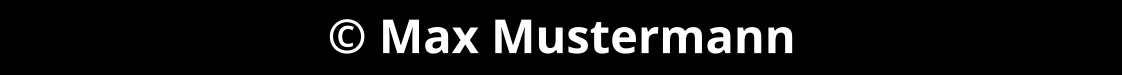

In [25]:
copyright

([], [])

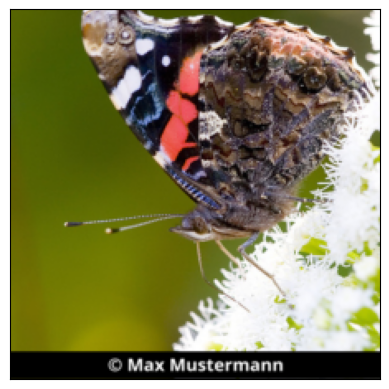

In [26]:
plt.imshow(
    rc_transform(utils.apply_copyright_to_image(image, copyright))
); plt.xticks([]); plt.yticks([])


([], [])

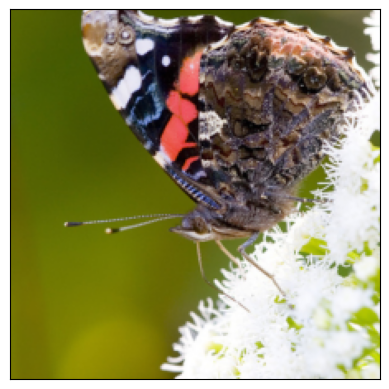

In [27]:
plt.imshow(
    rc_transform(image)
); plt.xticks([]); plt.yticks([])


In [28]:
from matplotlib.colors import ListedColormap
import numpy as np

def _heatmap(
    heatmap,
    title="",
    logit=None,
    reference_heatmap=None,
    total_score=None,
    fontsize="small",
    xlabel_prefix=""
):
    """Plot heatmap; this is adapted from https://git.tu-berlin.de/gmontavon/lrp-tutorial/-/blob/main/utils.py

    Args:
        heatmap np.array(h, w):
        reference_heatmap (np.array(h, w), optional): used for calculating normalization values. Defaults to None.
        total_score (float, optional): used for normalizing scores. Defaults to None.
    """
    assert len(heatmap.shape) == 2

    if reference_heatmap is None:
        reference_heatmap = heatmap

    assert len(reference_heatmap.shape) == 2

    b = np.abs(reference_heatmap).max()

    my_cmap = plt.cm.seismic(np.arange(plt.cm.seismic.N))
    my_cmap[:, 0:3] *= 0.85
    my_cmap = ListedColormap(my_cmap)

    sum_Ri = np.sum(heatmap)
    if total_score is None:
        percent = 100
        txt = r"%s $\sum_i R_i=%.2f$" % (xlabel_prefix, sum_Ri)
    else:
        percent = (sum_Ri / total_score) * 100
        txt = r"%s $\sum_i R_i=%.4f$ (%3.1f%%)" % (xlabel_prefix, sum_Ri, percent)

    plt.axis("on")
    plt.xticks([])
    plt.yticks([])
    plt.imshow(heatmap, cmap=my_cmap, vmin=-b, vmax=b)

    h = heatmap.shape[0]
    
    plt.title(f"{title}", fontsize=fontsize)
    if logit is not None:
        plt.xlabel(f"{txt}, logit={logit:.4f}", fontsize=fontsize)
    else:
        plt.xlabel(f"{txt}", fontsize=fontsize)
        

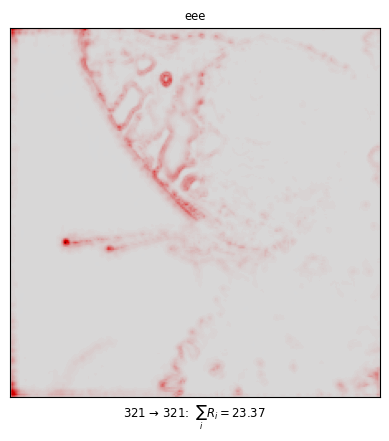

In [29]:
def get_attributor_for_model(model):
    
    normalizer = transforms.Normalize(
        mean=input_transform.mean,
        std=input_transform.std
    )
    
    low, high = normalizer(torch.tensor([[[[[0.0]]] * 3], [[[[1.0]]] * 3]]))

    composite = EpsilonGammaBox(low=low, high=high, canonizers=[])
    # todo: be careful here, because don't use any canonizer
    return Gradient(model=model, composite=composite)


def viz_heatmap(
    model, 
    img, 
    label, 
    num_classes,
    title="",
):
        
    data = input_transform(img)[None]
    
    logit_mod = lambda logits: logits * F.one_hot(torch.Tensor([label]).long(), num_classes)

    # create the attributor, specifying model
    with get_attributor_for_model(model) as attributor:
        # compute the model output and attribution
        output, attribution = attributor(data, logit_mod)
    
    heatmap = attribution.numpy().sum(axis=1).squeeze()
    output = output.detach().numpy().squeeze()
    ypred = np.argmax(output)
    
    _heatmap(
        heatmap, title=title, 
        xlabel_prefix=f"{label} → {ypred}: "
    )


viz_heatmap(teacher_model, image, teacher_label, num_classes=1000, title="eee")

In [30]:
wandapi = wandb.Api()

In [31]:
def load_trained_student_model(student, runid, num_classes=6):
    
    
    run =  wandapi.run(f"{PROJECT}/{runid}")
    policy = run.config["policy"]
    # todo: this suffix should be the one of the last epoch!
    # `latest` here is NOT necessary the last one, unless the checkpoint is specificy with the last.
    print(f"run_id={runid}")
    suffix = "latest"
    artifact = wandapi.artifact(f"{PROJECT}/model-{runid}:{suffix}")
    print(runid, suffix, artifact)

    artifact_dir = artifact.download()
    
    ckpt = torch.load(f"{artifact_dir}/model.ckpt", map_location=torch.device('cpu'))
    
    state_dict = ckpt["state_dict"]
    
    student_state_dict = dict()
    for key in state_dict.keys():
        if key.split(".")[0] == "student":
            student_state_dict[key] = state_dict[key]
            
    
        
    student = models.get_untrained_model(student, num_classes=num_classes)

    trainer_wrapper = nn.Sequential(OrderedDict([("student", student)]))
    trainer_wrapper.load_state_dict(student_state_dict)


    return student

def load_model_and_canonize(student, runid):
    
    trained_model = load_trained_student_model(student, runid)
    
    canonized_model = canonize_model(trained_model)
    canonized_model.eval()
    
    return canonized_model

def get_distill_model(
    dataset, 
    teacher, 
    student, 
    policy,
    lambda_layer,
    ignore_layer_loss_fullupdate,
    parameter_partition_mode,
    lambda_task=0.0,
    lambda_kd=1.0,
    training_size=0.125,
):
    
    df = read_data(
        teacher=teacher, 
        dataset=dataset,
        student=student,
        lambda_task=lambda_task,
        lambda_kd=lambda_kd,
        policy=policy,
        training_size=training_size,
        verbose=True,
        contamination_level=0.0,
        return_raw=True,
        lambda_layer=lambda_layer,
        parameter_partition_mode=parameter_partition_mode,
        ignore_layer_loss_fullupdate=ignore_layer_loss_fullupdate
    )
    
    
    df = df[(df.seed == 1) & (df.lambda_layer == lambda_layer)]

    run_id = df["run_id"].values[0]
    
    model = load_model_and_canonize(student, run_id)
    
    return model

get_distill_model(
    dataset="imagenet-butterfly", 
    teacher="imagenet-vgg16-tv",
    student="vggcustomimagenetdims-32-24-24-10",
    policy="basis-identity:pca--uncentered",
    lambda_layer=1.0,
    ignore_layer_loss_fullupdate=True,
    parameter_partition_mode="@50",
);

we have 3 runs
run_id=v1cb2wuu
v1cb2wuu latest <Artifact QXJ0aWZhY3Q6ODQ5NDM1ODM2>


wandb:   1 of 1 files downloaded.  


we have 3 runs
run_id=rs47rea2
rs47rea2 latest <Artifact QXJ0aWZhY3Q6ODQ5NDMyODk0>


wandb:   1 of 1 files downloaded.  


we have 3 runs
run_id=g4hdy7jc
g4hdy7jc latest <Artifact QXJ0aWZhY3Q6ODQ5NDQwMzMz>


wandb:   1 of 1 files downloaded.  


we have 3 runs
run_id=9to6qat1
9to6qat1 latest <Artifact QXJ0aWZhY3Q6ODQ5NDQzNTE3>


...

wandb:   1 of 1 files downloaded.  


we have 3 runs
run_id=iuh2s2iz
iuh2s2iz latest <Artifact QXJ0aWZhY3Q6ODQ5NDY5Njk4>


wandb:   1 of 1 files downloaded.  


we have 3 runs
run_id=zgjr8oxw
zgjr8oxw latest <Artifact QXJ0aWZhY3Q6ODQ5NDYyOTg0>


wandb:   1 of 1 files downloaded.  


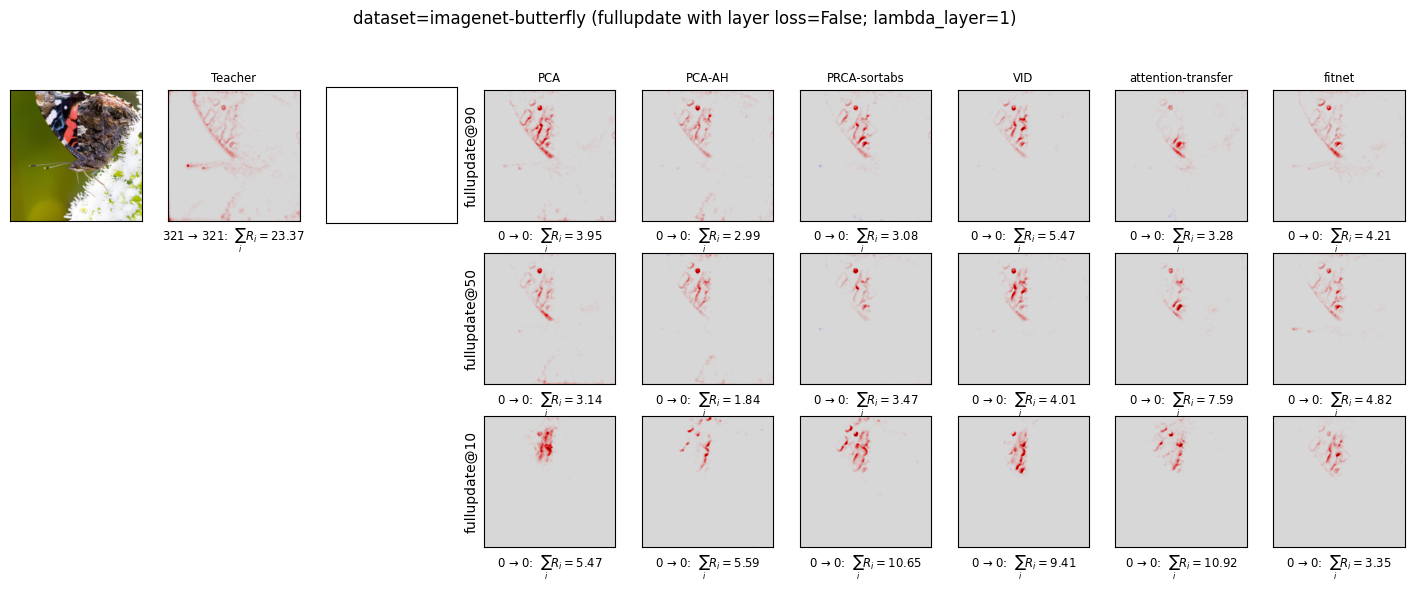

In [34]:
def viz_heatmap_comparison(
    image,
    dataset,
    arr_policies=[
        "basis-identity:pca--uncentered",  
        "basis-identity:pcalookahead--uncentered",        
        "basis-identity:prca-sortabs--uncentered",
        "vid", 
        "attention-transfer",
        "fitnet"
    ],
    ignore_layer_loss_fullupdate=True, 
    arr_parameter_partition_modes = [
        "@90", 
        "@50", 
        "@10"
    ]
):

    lambda_layer = 1
    
    assert dataset in ["imagenet-butterfly-spurious0.5", "imagenet-butterfly"]
    if dataset == "imagenet-butterfly-spurious0.5":
        image = utils.apply_copyright_to_image(image, copyright)
    
    teacher = "imagenet-vgg16-tv"
    student = "vggcustomimagenetdims-32-24-24-10"
    
    student_num_classes = len(ds.selected_classes)

    nrows = len(arr_parameter_partition_modes)
    ncols = 3 + len(arr_policies)
    
    plt.figure(figsize=(2*ncols, 2*nrows))

    plt.suptitle(
        f"dataset={dataset} (fullupdate with layer loss={not ignore_layer_loss_fullupdate}; lambda_layer={lambda_layer})", 
        y=1.01
    )
    
    plt.subplot(nrows, ncols, 1)
    
    plt.imshow(rc_transform(image)); plt.xticks([]); plt.yticks([])
    
    plt.subplot(nrows, ncols, 2)
    plt.title("Teacher")
    viz_heatmap(
        teacher_model, image, teacher_label, 
        num_classes=1000, title="Teacher"
    )
    
    plt.subplot(nrows, ncols, 3)
    """ TODO
    viz_heatmap(
         get_distill_model(
            dataset=dataset, 
            teacher=teacher,
            student=student,
            policy="nothing",
            lambda_layer=0
        ), 
        image, student_label,
        num_classes=student_num_classes,
        title=alias("nothing")
    )
    plt.xticks([]); plt.yticks([])
    """
    plt.xticks([]); plt.yticks([])

    for lix, parameter_mode in enumerate(arr_parameter_partition_modes):
        for pix, policy in enumerate(arr_policies):
            plt.subplot(nrows, ncols, ncols*lix + 4 + pix)
            
            distilled_model =  get_distill_model(
                dataset=dataset, 
                teacher=teacher,
                student=student,
                policy=policy,
                lambda_layer=lambda_layer,
                ignore_layer_loss_fullupdate=ignore_layer_loss_fullupdate,
                parameter_partition_mode=parameter_mode
            )

            viz_heatmap(
                distilled_model, image, student_label,
                num_classes=student_num_classes,
                title=alias(policy) if lix == 0 else ""
            )

            if pix == 0:
                plt.ylabel(f"fullupdate{parameter_mode}")
                
viz_heatmap_comparison(
    image=image,
    dataset="imagenet-butterfly"
)

we have 3 runs
run_id=qywuv4gb
qywuv4gb latest <Artifact QXJ0aWZhY3Q6ODQ5NDcxNjM5>


wandb:   1 of 1 files downloaded.  


we have 3 runs
run_id=sfuvhl7l
sfuvhl7l latest <Artifact QXJ0aWZhY3Q6ODQ5NDc2Nzc4>


wandb:   1 of 1 files downloaded.  


we have 3 runs
run_id=czfdm2ji
czfdm2ji latest <Artifact QXJ0aWZhY3Q6ODQ5NDgzNzQz>


...

wandb:   1 of 1 files downloaded.  


we have 3 runs
run_id=tym06lcw
tym06lcw latest <Artifact QXJ0aWZhY3Q6ODQ5NTU2MTM3>


wandb:   1 of 1 files downloaded.  


we have 3 runs
run_id=qw7fa0pv
qw7fa0pv latest <Artifact QXJ0aWZhY3Q6ODQ5NTQ3MjQ5>


wandb:   1 of 1 files downloaded.  


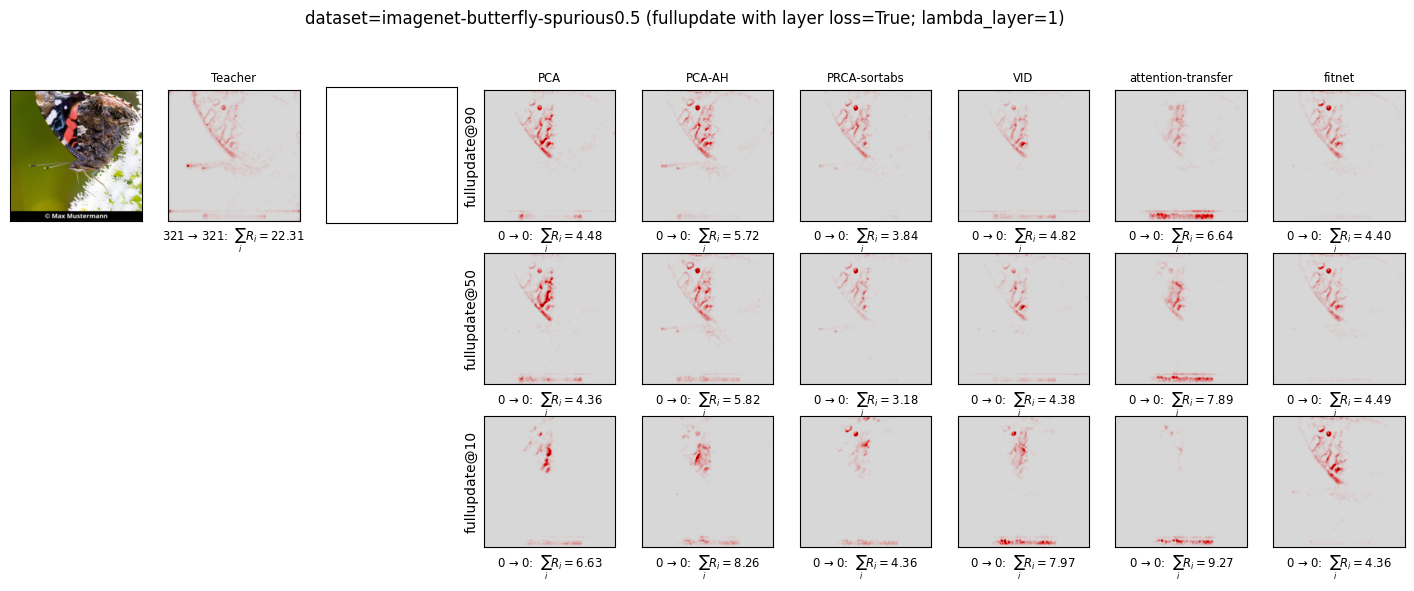

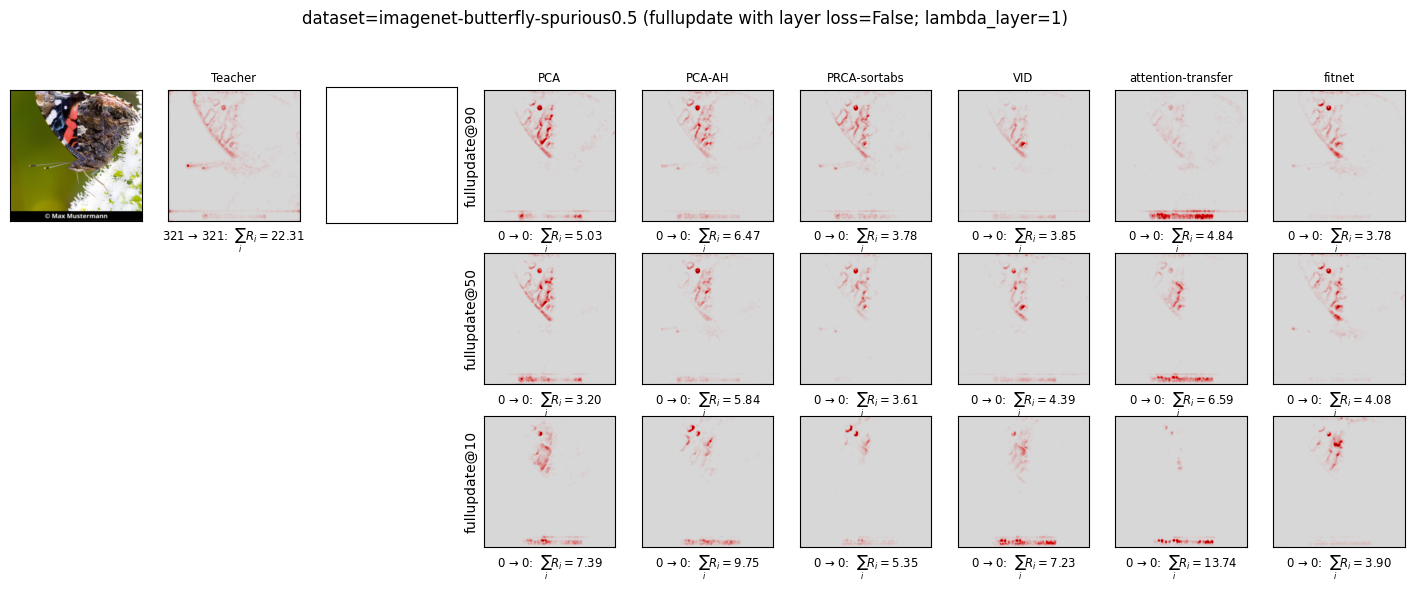

In [35]:
for ignore in [ False, True]:
    
    viz_heatmap_comparison(
        image=image,
        dataset="imagenet-butterfly-spurious0.5",
        ignore_layer_loss_fullupdate=ignore
    )